In [8]:
import torch
from monai.networks.nets import DynUNet
import torchio as tio
from pathlib import Path
import os
from torch.utils.data import random_split, DataLoader
from tqdm import tqdm
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

import ipywidgets as widgets
from IPython.display import display
import random
import numpy as np

In [9]:
# Set all random seed for reproducibility
random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)

In [10]:
# Constructing the model via the saved weights
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_path = '/home/user/Documents/raph/code/saved_models/best_model_UNet_StrokeLesion_nnUNet_aug_new_loss_20_patches_new_label_sampler_adam_dropout_200_epochs.pth'

# NETWORK ARCHITECTURE
#--------------------------------------------------------------------------------------
# Define network parameters
spatial_dims = 3
in_channels = 3
out_channels = 1
kernel_size = [[3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3]]
strides = [[1, 1, 1], [2, 2, 2], [2, 2, 2], [2, 2, 2], [2, 2, 2]]
up_sample_kernel_size = strides[1:]
filters = [32, 64, 128, 256, 320]
# default params
# - norm_name: instance
# - act_name: leaky relu (negative_slope 0.01)
# - dropout: None
    
# Initialize the DynUNet
model = DynUNet(
    spatial_dims=spatial_dims,
    in_channels=in_channels,
    out_channels=out_channels,
    kernel_size=kernel_size,
    strides=strides,
    upsample_kernel_size=up_sample_kernel_size,
    filters=filters,
    #dropout = dropout
)

# Loading the weights
state_dict = torch.load(weights_path)

# Loading the weights into the model
model.load_state_dict(state_dict)
model.to(DEVICE)

DynUNet(
  (input_block): UnetBasicBlock(
    (conv1): Convolution(
      (conv): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    )
    (conv2): Convolution(
      (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    )
    (lrelu): LeakyReLU(negative_slope=0.01, inplace=True)
    (norm1): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
    (norm2): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
  )
  (downsamples): ModuleList(
    (0): UnetBasicBlock(
      (conv1): Convolution(
        (conv): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      )
      (conv2): Convolution(
        (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      )
      (lrelu): LeakyReLU(negative_slope=0.01, inplace=True)
      (norm1): InstanceNorm3d(64, eps=1e-05, 

In [11]:
class BCEDiceLoss(nn.Module):
    """
    Compute the BCE Dice Loss

    Args:
    nn.Module: PyTorch module

    Returns:
    loss: float, containing the loss computed as bce + dice_loss
    dice_score: float, containing the Dice score
    bce: float, containing the BCE loss
    """
    def __init__(self, epsilon=1e-6):
        super(BCEDiceLoss, self).__init__()
        self.bce_loss = nn.BCELoss()
        self.epsilon = epsilon
 
    def forward(self, predictions, targets, is_validation=False):
        #Convert to float
        predictions = predictions.float()
        targets = targets.float()
        # Compute BCE Loss
        bce = self.bce_loss(predictions, targets)

        # Compute Dice Loss
        if is_validation:
            predictions = (predictions > 0.5).float() # Binarize the predictions for the validation set
        predictions_flat = predictions.reshape(predictions.size(0), -1)
        targets_flat = targets.reshape(targets.size(0), -1)
        intersection = (predictions_flat * targets_flat).sum(1)
        sum_pred_target = predictions_flat.sum(1) + targets_flat.sum(1)
        dice = (2. * intersection + self.epsilon) / (sum_pred_target + self.epsilon)

        dice_loss = 1 - dice.mean()
 
        # Combine BCE and Dice Loss
        loss = bce + dice_loss
        dice_score = dice.mean()
 
        return loss, dice_score, bce

criterion_val = BCEDiceLoss() # BCE + Dice loss for validation

In [12]:
# DATALOADER
#--------------------------------------------------------------------------------------

# Define the paths to your BIDS data (PREPROCESSED DATA!!!)
bids_dir = Path('/home/user/Documents/raph/preprocessed_datasets/ISLES2022')

# List all directories in the parent directory that start with 'sub-'
sub_folders = [p.name for p in bids_dir.iterdir() if p.is_dir() and p.name.startswith('sub-')]

# loop over all subjects to get relevant images/labels         
subjects = []
for subject_id in sub_folders:

    # get all images and labelmap of subject
    FLAIR_path = os.path.join(bids_dir, subject_id, "ses-0001", "anat", f"{subject_id}_ses-0001_FLAIR.nii.gz")
    dwi_path = os.path.join(bids_dir, subject_id, "ses-0001", "dwi", f"{subject_id}_ses-0001_dwi.nii.gz")
    adc_path = os.path.join(bids_dir, subject_id, "ses-0001", "dwi", f"{subject_id}_ses-0001_ADC.nii.gz")
    mask_path = os.path.join(bids_dir, "derivatives", subject_id, "ses-0001", f"{subject_id}_ses-0001_msk.nii.gz")

    # create a subject
    subject = tio.Subject(
        flair=tio.ScalarImage(FLAIR_path),
        dwi=tio.ScalarImage(dwi_path),
        adc=tio.ScalarImage(adc_path),
        label=tio.LabelMap(mask_path),
    )

    # add subject to list
    subjects.append(subject)

# create the SubjectsDataset
dataset = tio.SubjectsDataset(subjects, transform=None)

# split data into training and validation set
test_size = 50
train_percent = 0.8
train_size = int(train_percent * (len(dataset) - 50)) #160
val_size = len(dataset) - train_size - test_size #40

train_indices, val_indices = random_split(range(len(dataset) - 50), [train_size, val_size])

val_subjects = [subjects[i] for i in val_indices]

val_dataset = tio.SubjectsDataset(val_subjects, transform=None)

# PATCHED TRAINING SET

batch_size_train = 4
patch_size_train = 128
samples_per_volume = 20
max_queue_length = 50

In [13]:
# Analysis of the results:

def boxplot(dice_scores):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=dice_scores, color='lightblue', fliersize=0)  # Use a light color for the boxplot
    sns.swarmplot(data=dice_scores, color='darkblue')  # Plot individual scores in a darker color
    plt.title("DICE Boxplot with Individual Scores")
    plt.ylabel("Score DICE")
    plt.xlabel("Images")
    plt.show()

def overlay(image, label, prediction, slice_index, label_opacity, prediction_opacity, dice):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image[:, :, slice_index], cmap='gray')  # Assuming the 3rd dimension is the slice
    ax.imshow(label[:, :, slice_index], cmap='Reds', alpha=label_opacity)
    ax.imshow(prediction[:, :, slice_index], cmap='Blues', alpha=prediction_opacity)
    plt.title(f'Dice: {dice:.2f}')
    plt.axis('off')
    plt.show()

def interactive_overlay(image, label, prediction, dice):
    slice_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=image.shape[2] - 1,  # Assuming the 3rd dimension is the slice
        step=1,
        description='Slice:',
        continuous_update=False
    )
    label_opacity_slider = widgets.FloatSlider(
        value=0.5,
        min=0,
        max=1.0,
        step=0.1,
        description='Label Opacity:',
        continuous_update=False
    )
    prediction_opacity_slider = widgets.FloatSlider(
        value=0.5,
        min=0,
        max=1.0,
        step=0.1,
        description='Prediction Opacity:',
        continuous_update=False
    )
    ui = widgets.VBox([
        slice_slider,
        label_opacity_slider,
        prediction_opacity_slider
    ])
    out = widgets.interactive_output(overlay, {
        'image': widgets.fixed(image),
        'label': widgets.fixed(label),
        'prediction': widgets.fixed(prediction),
        'slice_index': slice_slider,
        'label_opacity': label_opacity_slider,
        'prediction_opacity': prediction_opacity_slider,
        'dice': widgets.fixed(dice)

    })
    display(ui, out)


  0%|          | 0/40 [00:00<?, ?it/s]

Output()

  2%|▎         | 1/40 [00:03<02:17,  3.53s/it]

Output()

  5%|▌         | 2/40 [00:07<02:15,  3.56s/it]

...

 95%|█████████▌| 38/40 [02:20<00:07,  3.73s/it]

Output()

 98%|█████████▊| 39/40 [02:24<00:03,  3.71s/it]

Output()

100%|██████████| 40/40 [02:28<00:00,  3.71s/it]


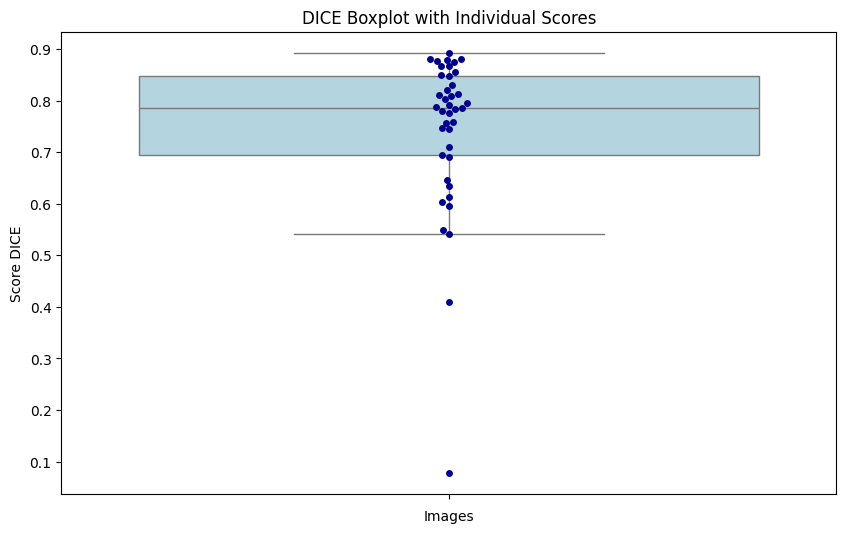

Median DICE score: 0.79, std: 0.15


In [14]:
# batch size used in validation
batch_size_val = 4

# patch size and overlap for gridSampler used in validation
patch_size_val = 128
patch_overlap_val = 64

# init
best_metric = -1
best_metric_epoch = -1
metric_values = []
    
# VALIDATION
dice_scores = []

model.eval()

# loop over all subject in validation set
for subject in tqdm(val_dataset):
    # define GridSampler for current subject
    grid_sampler = tio.inference.GridSampler(
        subject = subject,  
        patch_size = patch_size_val,
        patch_overlap = patch_overlap_val,
        padding_mode = 'constant'
    )
    patch_loader = torch.utils.data.DataLoader(grid_sampler, batch_size = batch_size_val)
    aggregator = tio.inference.GridAggregator(grid_sampler, overlap_mode = 'hann')
    
    # loop over patches to get model predictions
    for patches_batch in patch_loader:
        patch_inputs = torch.cat([patches_batch['flair'][tio.DATA], patches_batch['dwi'][tio.DATA], patches_batch['adc'][tio.DATA]], dim=1).to(DEVICE)
        patch_locations = patches_batch[tio.LOCATION]
        with torch.no_grad():
            patch_prediction = model(patch_inputs)
        patch_prediction_logits = torch.sigmoid(patch_prediction)
        aggregator.add_batch(patch_prediction_logits, patch_locations)

    # aggregate over patches
    aggregated_logits = aggregator.get_output_tensor()
    
    # compute validation dice and loss
    ground_truth_seg = subject['label'][tio.DATA]
    
    loss_val, dice, BCE = criterion_val(aggregated_logits, ground_truth_seg, is_validation=True)            
    dice_scores.append(dice.item())
    
    # Visualisation of the results by overlaying the FLAIR image with the groundtruth (in red) and the prediction mask (in blue) on the same image:
    flair = subject['flair'][tio.DATA].squeeze().numpy()
    ground_truth = ground_truth_seg.squeeze().numpy()
    prediction = aggregated_logits.squeeze().cpu().numpy()
    interactive_overlay(flair, ground_truth, prediction, dice.item())

boxplot(dice_scores)
print(f'Median DICE score: {np.median(dice_scores):.2f}, std: {np.std(dice_scores):.2f}')
